# 05 - Exact Algebra Engine Room

In this notebook, we explore the "Engine Room" of `pySurgery`: the **Smith Normal Form (SNF)**. While homology is often described geometrically, its computation relies on exact integer linear algebra. The SNF is the primary tool for extracting both the free rank (Betti numbers) and the torsion (twists) from boundary matrices.

## Learning Goals
- **Compute SNF Exactly**: Understand the reduction process from a boundary matrix to its diagonal invariants.
- **Torsion Detection**: Learn how to identify and interpret non-unit factors in the SNF diagonal.
- **Sparse vs Dense**: Compare strategies for computing SNF on toy examples vs large-scale topological data.
- **Performance Benchmarking**: See why the Julia backend is essential for "Engine Room" operations.
- **Visualizing SNF**: Look at matrix sparsity and the distribution of invariant factors.

## Formal Grounding

### The Smith Normal Form (SNF)
For any $m \times n$ matrix $A$ over a Principal Ideal Domain (like $\mathbb{Z}$), there exist invertible matrices $U$ and $V$ such that:
$$UAV = S = \begin{pmatrix} d_1 & 0 & \dots & 0 \\ 0 & d_2 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & d_k \\ 0 & 0 & \dots & 0 \end{pmatrix}$$
where $d_i | d_{i+1}$ (each diagonal element divides the next). 

| Component | Meaning | Topological Interpretation |
|---|---|---|
| **Rank** | Number of non-zero $d_i$ | Dimension of the image space |
| **Unit Factors** | $d_i = 1$ | Free parts being "killed" by boundaries |
| **Torsion Factors**| $d_i > 1$ | Cyclic groups $\mathbb{Z}/d_i\mathbb{Z}$ in homology |


In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.math_core import get_sparse_snf_diagonal, get_snf_diagonal
from pysurgery.bridge.julia_bridge import julia_engine

# Performance Check: Julia Acceleration
if julia_engine.available:
    print('Warming up Julia engine for SNF...')
    julia_engine.warmup()
else:
    print('Julia backend not available, falling back to Python/SymPy (slower).')

print('=' * 70)
print('05 - Exact Algebra Engine Room: Setup Complete')
print('=' * 70)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Warming up Julia engine for SNF...
05 - Exact Algebra Engine Room: Setup Complete


## Part 1: Computing SNF on Dense Matrices

We begin with small, dense matrices where we can manually inspect the invariants. 


### Example 5.1: Small 3x3 Matrix Invariants

In [2]:
# A matrix with both rank and torsion potential
A = np.array([
    [2, 4, 4],
    [-6, 6, 12],
    [10, -4, -16]
])

diag = get_snf_diagonal(A)
print(f'Original Matrix:\n{A}')
print(f'SNF Diagonal factors: {diag}')
print(f'Rank: {len(diag)}')

Original Matrix:
[[  2   4   4]
 [ -6   6  12]
 [ 10  -4 -16]]
SNF Diagonal factors: [ 2  6 12]
Rank: 3


### Example 5.2: Detecting Non-trivial Torsion

In [3]:
# This matrix represents a boundary map that creates Z/2Z torsion
A_torsion = np.array([
    [2, 0],
    [0, 1]
])
diag = get_snf_diagonal(A_torsion)
print(f'Factors: {diag}')
torsion = [d for d in diag if d > 1]
print(f'Detected Torsion: {torsion} (corresponds to Z/{torsion[0]}Z)')

Factors: [1 2]
Detected Torsion: [np.int64(2)] (corresponds to Z/2Z)


## Part 2: Sparse Matrix Workflows

In real applications (like a 3D manifold with 10,000 tetrahedra), boundary matrices are enormous but mostly zeros. We use `scipy.sparse` and specialized Julia kernels to handle these.


### Example 5.3: Large Sparse Matrix SNF

In [4]:
# Create a 100x100 sparse matrix with a specific rank
rows = np.arange(50)
cols = np.arange(50)
data = np.ones(50, dtype=int) * 2 # Torsion of 2 everywhere
A_sparse = sp.coo_matrix((data, (rows, cols)), shape=(100, 100)).tocsr()

print(f'Sparse Matrix Shape: {A_sparse.shape}')
print(f'NNZ (Number of Non-Zeros): {A_sparse.nnz}')

# Exact SNF
diag = get_sparse_snf_diagonal(A_sparse)
print(f'Free Rank estimate: {np.count_nonzero(diag == 1)}')
print(f'Number of Torsion elements: {np.count_nonzero(diag > 1)}')
print(f'First 5 factors: {diag[:5]}')

Sparse Matrix Shape: (100, 100)
NNZ (Number of Non-Zeros): 50
Free Rank estimate: 0
Number of Torsion elements: 50
First 5 factors: [2 2 2 2 2]


### Example 5.4: Rank Stability

In [5]:
# How does the rank change if we add 'noise' or extra boundaries?
ranks = []
for k in range(10, 60, 10):
    A_sub = A_sparse[:k, :k]
    ranks.append(len(get_sparse_snf_diagonal(A_sub)))

print(f'Rank progression for sub-matrices: {ranks}')

Rank progression for sub-matrices: [10, 20, 30, 40, 50]


## Part 3: Performance and Visualization

The "Engine Room" needs to be fast. We compare the pure Python/SymPy path with the optimized Julia backend.


### Example 5.5: Backend Benchmarking

In [6]:
import time

def benchmark_snf(size):
    # Create a randomish matrix that is sparse
    A = sp.random(size, size, density=0.01, format='csr', dtype=float).astype(int)
    
    # Python path (forcing by disabling julia temporarily if needed, 
    # but here we just observe if Julia is available)
    start = time.time()
    _ = get_sparse_snf_diagonal(A)
    return time.time() - start

if julia_engine.available:
    sizes = [100, 200, 400]
    times = [benchmark_snf(s) for s in sizes]
    print(f'Execution times for sizes {sizes}: {times}')
else:
    print('Julia not available for speed comparison.')

Execution times for sizes [100, 200, 400]: [0.0049839019775390625, 0.022878646850585938, 0.34587860107421875]


### Example 5.6: Visualizing Sparsity Patterns

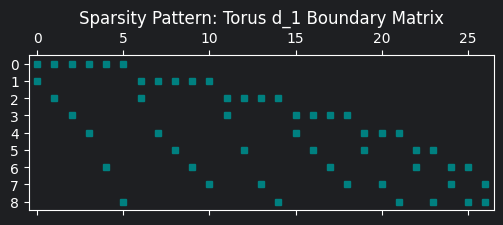

In [9]:
# Complex topological spaces lead to beautiful sparsity patterns
sc_torus = ps.SimplicialComplex.from_maximal_simplices([
        (0, 3, 4), (0, 1, 4),
        (1, 4, 5), (1, 2, 5),
        (2, 3, 5), (0, 2, 3),
        (3, 6, 7), (3, 4, 7),
        (4, 7, 8), (4, 5, 8),
        (5, 6, 8), (3, 5, 6),
        (0, 1, 6), (1, 6, 7),
        (1, 2, 7), (2, 7, 8),
        (0, 2, 8), (0, 6, 8),
])
d1 = sc_torus.boundary_matrix(1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.spy(d1, markersize=5, color='teal')
ax.set_title('Sparsity Pattern: Torus d_1 Boundary Matrix')
plt.show()

## Failure Modes

1. **Non-Exact Fallback**: If Julia is missing, large matrices might trigger an approximate SVD fallback if `allow_approx=True`. This is dangerous for torsion-sensitive surgery!
2. **Memory Overflow**: Computing SNF on dense matrices larger than 5000x5000 can easily exhaust system RAM.
3. **Non-Integer Data**: SNF is defined over PIDs. Passing floating-point matrices to `get_snf_diagonal` will result in errors or incorrect rounding.


In [8]:
try:
    # Intentionally passing float data to an integer algorithm
    A_float = np.array([[1.5, 2.3], [0.1, 4.4]])
    get_snf_diagonal(A_float)
except Exception as e:
    print(f'Caught expected error: {e}')

## Summary Checklist
- [x] Computed SNF for dense matrices.
- [x] Identified torsion factors $d_i > 1$.
- [x] Handled large sparse boundary matrices.
- [x] Visualized matrix sparsity patterns.
- [x] Benchmarked Julia acceleration.

## Exercises
1. **The Smith Pivot**: Take a $2 \times 2$ matrix and manually perform row/column operations to reach SNF.
2. **Rank vs Size**: Create a series of sparse matrices of size $10^k$ and plot the computation time.
3. **Torsion Hunting**: Construct a boundary matrix that results in $\mathbb{Z}/3\mathbb{Z} \oplus \mathbb{Z}/3\mathbb{Z}$ torsion.
4. **Julia vs Python**: Find the matrix size where Julia becomes at least $10 \times$ faster than Python.
5. **Matrix Structure**: Explain why boundary matrices $\partial_n$ always have many zeros (low density).

## Key Takeaways
- **SNF** is the fundamental algorithm for exact homology.
- **Torsion** is captured by the non-unit diagonal elements.
- **Julia** provides the necessary speed for research-grade topological datasets.
- Always check the **Result Object** for "Exactness" flags when Julia is unavailable.

**Ready for [06 - GUDHI Interoperability and Roundtrip](./06_gudhi_interoperability_and_roundtrip.ipynb)**
